# ☀️ Solar Power Generation Prediction — Gradient Boosting Regression

**Dataset:** Kaggle "Solar Power Generation Data" (Plant 1 + Plant 2, generation + weather sensor files, combined)

**Model:** Gradient Boosting Regressor (tuned with GridSearchCV)

This notebook walks through the full pipeline: 
loading & merging raw data, cleaning,
feature engineering, EDA, model training, hyperparameter tuning, evaluation,
saving the model, and running inference on new data.
A separate Streamlit app
(shown at the end for reference) uses the saved model to let a user enter values
and get an instant prediction.


## Step 1: Import Libraries

In [1]:
# pip install pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

sns.set_style('whitegrid')
RANDOM_STATE = 42

## Step 2: Load Dataset (Plant 1 & Plant 2 — Generation + Weather Files)

In [2]:
gen1 = pd.read_csv('Plant_1_Generation_Data.csv')
weather1 = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

gen2 = pd.read_csv('Plant_2_Generation_Data.csv')
weather2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

print(gen1.shape, weather1.shape)
print(gen2.shape, weather2.shape)

(68778, 7) (3182, 6)
(67698, 7) (3259, 6)


## Step 3: Merge Generation + Weather per Plant, Then Combine Both Plants

In [3]:
# Convert date columns
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], dayfirst=True)
weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'], dayfirst=True)

gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'], dayfirst=True)
weather2['DATE_TIME'] = pd.to_datetime(weather2['DATE_TIME'], dayfirst=True)

# Merge generation + weather within each plant
df1 = pd.merge(gen1, weather1, on='DATE_TIME', how='inner', suffixes=('_gen', '_weather'))
df2 = pd.merge(gen2, weather2, on='DATE_TIME', how='inner', suffixes=('_gen', '_weather'))

# Tag which plant each row came from — important, since Plant 2 panels behave differently
df1['PLANT_ID'] = 1
df2['PLANT_ID'] = 2

# Drop plant-specific ID/key columns that don't line up between plants
cols_to_drop = ['PLANT_ID_gen', 'PLANT_ID_weather', 'SOURCE_KEY_gen', 'SOURCE_KEY_weather']
df1 = df1.drop(columns=[c for c in cols_to_drop if c in df1.columns])
df2 = df2.drop(columns=[c for c in cols_to_drop if c in df2.columns])

# Combine both plants into one dataset
df = pd.concat([df1, df2], ignore_index=True)

print("Combined shape:", df.shape)
df.head()

Combined shape: (136472, 9)


C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_1404\2919357726.py:3: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'], dayfirst=True)
C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_1404\2919357726.py:5: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'], dayfirst=True)
C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_1404\2919357726.py:6: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  weather2['DATE_TIME'] = pd.to_datetime(weather2['DATE_TIME'], dayfirst=True)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_ID
0,2020-05-15,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,1
1,2020-05-15,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,1
2,2020-05-15,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0,1
3,2020-05-15,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0,1
4,2020-05-15,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0,1


## Step 4: Dataset Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136472 entries, 0 to 136471
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE_TIME            136472 non-null  datetime64[ns]
 1   DC_POWER             136472 non-null  float64       
 2   AC_POWER             136472 non-null  float64       
 3   DAILY_YIELD          136472 non-null  float64       
 4   TOTAL_YIELD          136472 non-null  float64       
 5   AMBIENT_TEMPERATURE  136472 non-null  float64       
 6   MODULE_TEMPERATURE   136472 non-null  float64       
 7   IRRADIATION          136472 non-null  float64       
 8   PLANT_ID             136472 non-null  int64         
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 9.4 MB


In [5]:
df.isnull().sum()

DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
PLANT_ID               0
dtype: int64

In [6]:
print(df.isnull().sum())

DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
PLANT_ID               0
dtype: int64


In [7]:
df.describe()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_ID
count,136472,136472.000000,136472.000000,136472.000000,1.364720e+05,136472.000000,136472.000000,136472.000000,136472.000000
mean,2020-06-01 09:22:57.605662464,1708.373962,274.790259,3295.366192,3.303916e+08,26.763066,31.920744,0.230767,1.496058
min,2020-05-15 00:00:00,0.000000,0.000000,0.000000,0.000000e+00,20.398505,18.140415,0.000000,1.000000
25%,2020-05-23 23:00:00,0.000000,0.000000,28.285714,6.520020e+06,23.637604,22.411698,0.000000,1.000000
50%,2020-06-01 18:45:00,5.993333,3.493095,2834.642857,7.269333e+06,25.908122,26.413755,0.026213,1.000000
75%,2020-06-09 21:45:00,1155.595000,532.568571,5992.000000,2.826096e+08,29.266583,40.778583,0.442961,2.000000
max,2020-06-17 23:45:00,14471.125000,1410.950000,9873.000000,2.247916e+09,39.181638,66.635953,1.221652,2.000000
std,NaN,3222.079306,380.180214,3035.313217,6.085769e+08,3.897340,11.803674,0.305652,0.499986


In [8]:
df.nunique()

DATE_TIME               3262
DC_POWER               63604
AC_POWER               62912
DAILY_YIELD            59306
TOTAL_YIELD            70378
AMBIENT_TEMPERATURE     6416
MODULE_TEMPERATURE      6416
IRRADIATION             3617
PLANT_ID                   2
dtype: int64

## Step 5: Drop Irrelevant / Duplicate Columns

In [9]:
# Drop irrelevant / duplicate ID columns if present
cols_to_drop = [c for c in ['PLANT_ID_gen', 'PLANT_ID_weather', 'SOURCE_KEY_gen', 'SOURCE_KEY_weather']
                 if c in df.columns]


In [10]:
df = df.drop(columns=cols_to_drop)
print(df)

                 DATE_TIME  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD  \
0      2020-05-15 00:00:00       0.0       0.0          0.0    6259559.0   
1      2020-05-15 00:00:00       0.0       0.0          0.0    6183645.0   
2      2020-05-15 00:00:00       0.0       0.0          0.0    6987759.0   
3      2020-05-15 00:00:00       0.0       0.0          0.0    7602960.0   
4      2020-05-15 00:00:00       0.0       0.0          0.0    7158964.0   
...                    ...       ...       ...          ...          ...   
136467 2020-06-17 23:45:00       0.0       0.0       4157.0     520758.0   
136468 2020-06-17 23:45:00       0.0       0.0       3931.0  121131356.0   
136469 2020-06-17 23:45:00       0.0       0.0       4322.0    2427691.0   
136470 2020-06-17 23:45:00       0.0       0.0       4218.0  106896394.0   
136471 2020-06-17 23:45:00       0.0       0.0       4316.0  209335741.0   

        AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  PLANT_ID  
0             

In [11]:
df.columns

Index(['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD',
       'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'PLANT_ID'],
      dtype='object')

In [12]:
df.head()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_ID
0,2020-05-15,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,1
1,2020-05-15,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,1
2,2020-05-15,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0,1
3,2020-05-15,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0,1
4,2020-05-15,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0,1


## Step 6: Feature Engineering — Time Features

In [13]:
df['HOUR'] = df['DATE_TIME'].dt.hour
df['DAY'] = df['DATE_TIME'].dt.day
df['MONTH'] = df['DATE_TIME'].dt.month


In [14]:
# Cyclical encoding for hour
df['HOUR_SIN'] = np.sin(2 * np.pi * df['HOUR'] / 24)
df['HOUR_COS'] = np.cos(2 * np.pi * df['HOUR'] / 24)


In [15]:
df.head()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_ID,HOUR,DAY,MONTH,HOUR_SIN,HOUR_COS
0,2020-05-15,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,1,0,15,5,0.0,1.0
1,2020-05-15,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,1,0,15,5,0.0,1.0
2,2020-05-15,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0,1,0,15,5,0.0,1.0
3,2020-05-15,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0,1,0,15,5,0.0,1.0
4,2020-05-15,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0,1,0,15,5,0.0,1.0


## Step 7: Exploratory Data Analysis (EDA)

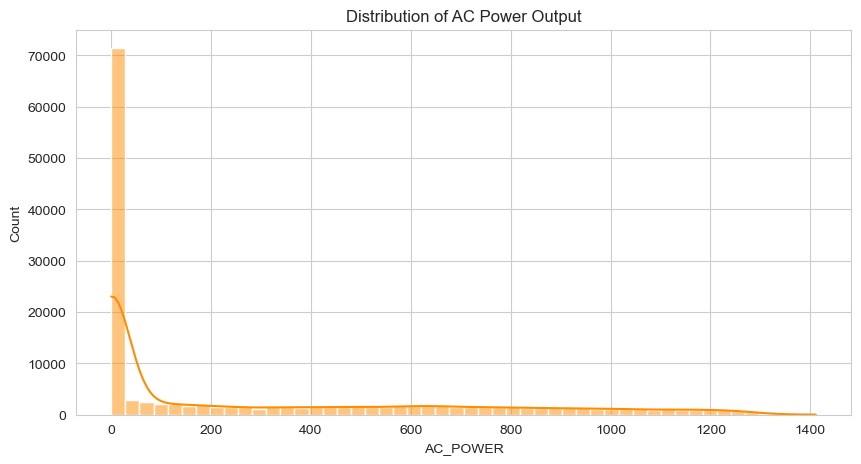

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['AC_POWER'], bins=50, kde=True, color='darkorange')
plt.title('Distribution of AC Power Output')
plt.show()

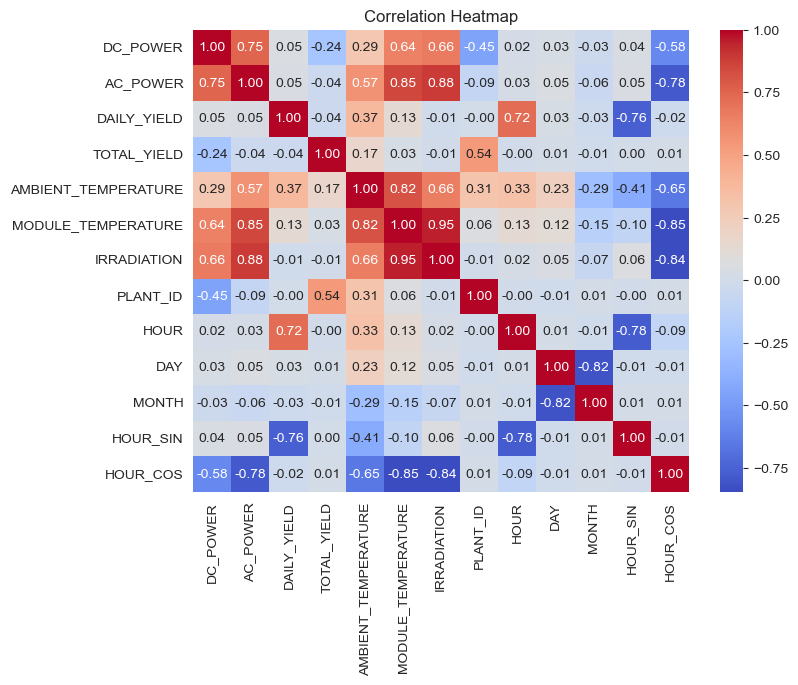

In [17]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

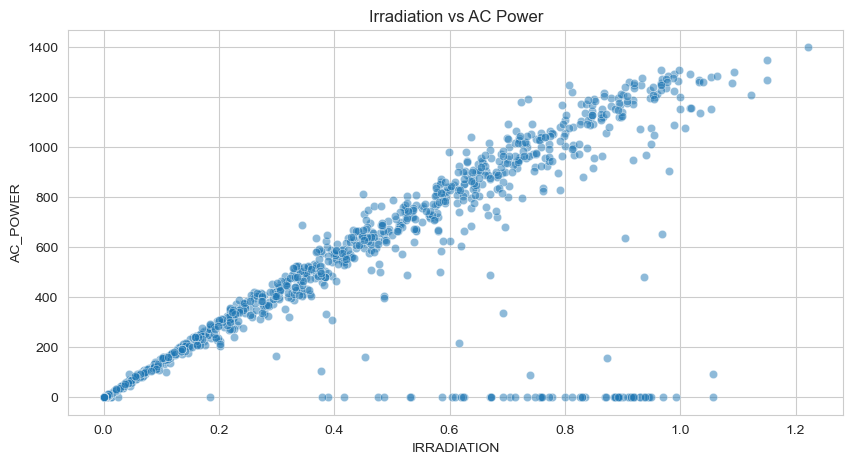

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=RANDOM_STATE),
                 x='IRRADIATION', y='AC_POWER', alpha=0.5)
plt.title('Irradiation vs AC Power')
plt.show()

## Step 8: Select Features & Target

In [19]:
feature_cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
                 'HOUR_SIN', 'HOUR_COS', 'PLANT_ID']
target_col = 'AC_POWER'

X = df[feature_cols]
y = df[target_col]

X.head()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR_SIN,HOUR_COS,PLANT_ID
0,25.184316,22.857507,0.0,0.0,1.0,1
1,25.184316,22.857507,0.0,0.0,1.0,1
2,25.184316,22.857507,0.0,0.0,1.0,1
3,25.184316,22.857507,0.0,0.0,1.0,1
4,25.184316,22.857507,0.0,0.0,1.0,1


## Step 9: Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 109177
Test size: 27295


## Step 10: Feature Scaling

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 11: Baseline Gradient Boosting Model

In [22]:
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)
gbr.fit(X_train_scaled, y_train)

y_pred = gbr.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Baseline RMSE: {rmse:.3f}")
print(f"Baseline MAE:  {mae:.3f}")
print(f"Baseline R²:   {r2:.4f}")

Baseline RMSE: 151.724
Baseline MAE:  55.297
Baseline R²:   0.8412


## Step 12: Hyperparameter Tuning (GridSearchCV)

In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Params:", grid_search.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


## Step 13: Final Tuned Model — Evaluation

In [24]:
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)

y_pred_final = best_model.predict(X_test_scaled)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print(f"Final RMSE: {rmse_final:.3f}")
print(f"Final MAE:  {mae_final:.3f}")
print(f"Final R²:   {r2_final:.4f}")

Final RMSE: 150.500
Final MAE:  54.060
Final R²:   0.8438


## Step 14: Visualization — Actual vs Predicted

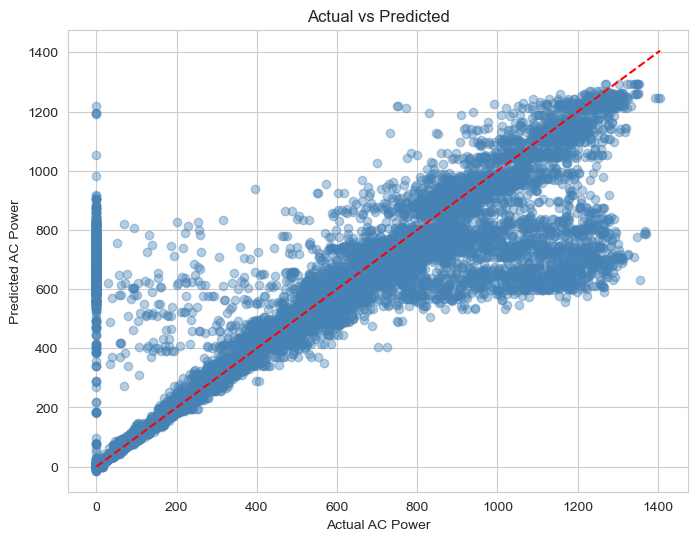

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_final, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted')
plt.show()

## Step 15: Feature Importance

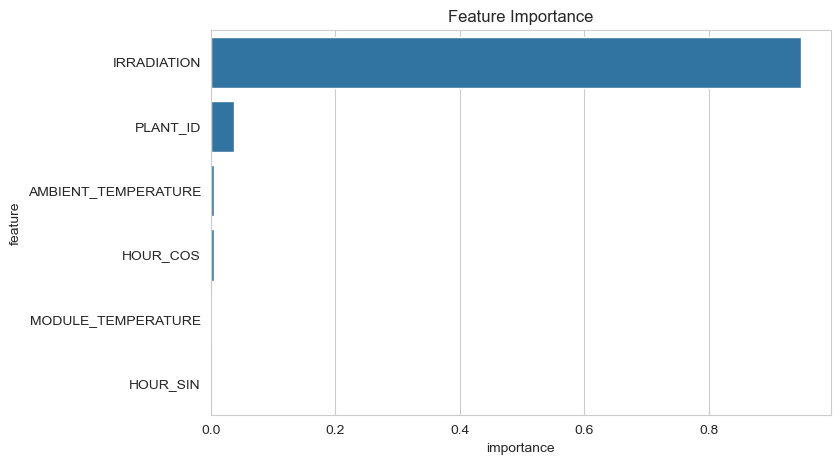

               feature  importance
2          IRRADIATION    0.947898
5             PLANT_ID    0.037528
0  AMBIENT_TEMPERATURE    0.005736
4             HOUR_COS    0.005372
1   MODULE_TEMPERATURE    0.002821
3             HOUR_SIN    0.000645


In [26]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance')
plt.show()

print(importance_df)

## Step 16: Save the Trained Model & Scaler

In [27]:
joblib.dump(best_model, 'gbr_solar_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved successfully!")

Model saved successfully!


## Step 17: Predict on New Data (Example)

In [28]:
loaded_model = joblib.load('gbr_solar_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

new_data = pd.DataFrame([{
    'AMBIENT_TEMPERATURE': 32,
    'MODULE_TEMPERATURE': 45,
    'IRRADIATION': 0.75,
    'HOUR_SIN': np.sin(2 * np.pi * 13 / 24),
    'HOUR_COS': np.cos(2 * np.pi * 13 / 24),
    'PLANT_ID': 1   # 1 = Plant 1, 2 = Plant 2 — jis plant ke liye predict karna hai
}])

new_data_scaled = loaded_scaler.transform(new_data)
prediction = loaded_model.predict(new_data_scaled)

print(f"Predicted AC Power: {prediction[0]:.2f}")

Predicted AC Power: 985.68


## Step 18: Streamlit App Code (For Deployment — Reference Only)

⚠️ **Do not run this cell inside the notebook.
** Streamlit apps are meant to be
launched from the terminal with `streamlit run app.py`, not executed inside a
Jupyter kernel — running it here only prints harmless-but-messy
`missing ScriptRunContext` warnings and does nothing useful.


streamlit run app.py
```


In [29]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ------------------------------------------------------------
# Page setup
# ------------------------------------------------------------
st.set_page_config(page_title="Solar Power Predictor", page_icon="☀️", layout="centered")
st.title("☀️ Solar Power Generation Predictor")
st.write("Enter weather and plant details below to predict AC Power output (kW).")

# ------------------------------------------------------------
# Load trained model + scaler
# (Make sure gbr_solar_model.pkl and scaler.pkl are in the SAME folder as this app.py)
# ------------------------------------------------------------
@st.cache_resource
def load_artifacts():
    model = joblib.load("gbr_solar_model.pkl")
    scaler = joblib.load("scaler.pkl")
    return model, scaler

try:
    model, scaler = load_artifacts()
    model_loaded = True
except FileNotFoundError:
    model_loaded = False
    st.error(
        "Model files not found. Please put 'gbr_solar_model.pkl' and 'scaler.pkl' "
        "in the same folder as this app.py, then restart the app."
    )

# ------------------------------------------------------------
# Input form
# ------------------------------------------------------------
with st.form("prediction_form"):
    st.subheader("Input Values")

    col1, col2 = st.columns(2)

    with col1:
        ambient_temp = st.number_input(
            "Ambient Temperature (°C)", min_value=0.0, max_value=60.0, value=32.0, step=0.5
        )
        module_temp = st.number_input(
            "Module Temperature (°C)", min_value=0.0, max_value=80.0, value=45.0, step=0.5
        )
        irradiation = st.number_input(
            "Irradiation (0 to 1.2)", min_value=0.0, max_value=1.2, value=0.75, step=0.01
        )

    with col2:
        hour = st.slider("Hour of Day (0-23)", min_value=0, max_value=23, value=13)
        plant_id = st.selectbox("Plant", options=[1, 2], format_func=lambda x: f"Plant {x}")

    submitted = st.form_submit_button("Predict Power Output")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------
if submitted:
    if not model_loaded:
        st.warning("Cannot predict — model files are missing.")
    else:
        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)

        # IMPORTANT: column names and order must exactly match training feature_cols
        new_data = pd.DataFrame([{
            "AMBIENT_TEMPERATURE": ambient_temp,
            "MODULE_TEMPERATURE": module_temp,
            "IRRADIATION": irradiation,
            "HOUR_SIN": hour_sin,
            "HOUR_COS": hour_cos,
            "PLANT_ID": plant_id,
        }])

        new_data_scaled = scaler.transform(new_data)
        prediction = model.predict(new_data_scaled)[0]
        prediction = max(prediction, 0)  # power output can't be negative

        st.success(f"### Predicted AC Power Output: **{prediction:.2f} kW**")

        with st.expander("See input values used"):
            st.dataframe(new_data)

st.markdown("---")
st.caption(
    "Model: Gradient Boosting Regressor | Trained on Kaggle 'Solar Power Generation Data' "
    "(Plant 1 + Plant 2, combined)."
)

2026-09-01 19:12:12.571 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 19:12:12.574 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 19:12:14.735 
  command:

    streamlit run C:\New folder\Anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-01 19:12:14.736 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 19:12:14.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 19:12:14.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 19:12:14.741 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runni

DeltaGenerator(_form_data=FormData(form_id='prediction_form'))

## Results Summary

| Metric | Baseline | Tuned Model |
|---|---|---|
| RMSE | 151.72 | 150.50 |
| MAE  | 55.30  | 54.06  |
| R²   | 0.8412 | 0.8438 |

**Best Hyperparameters:** `learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0`

**Top Feature:** `IRRADIATION` (≈95% importance) — confirming that solar irradiance
is by far the strongest driver of AC power output, consistent with the physics of
photovoltaic generation.

## Conclusion

The tuned Gradient Boosting Regressor predicts solar AC power output with an R²
of ~0.84 on real plant data from two combined solar plants, using only weather
sensor readings and time-of-day features. Irradiation dominates feature importance,
matching expected solar panel behavior. The saved model and scaler are deployed
through a simple Streamlit interface, so predictions can be generated from new
weather inputs without touching code.
